## import libraries

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, make_scorer

## define functions

In [2]:
def metric_results(y_train, y_train_pred, y_test, y_test_pred, ndigits=2, target_unit="target"):
    
    mean_load_test = y_test.mean()
    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rel_mae_test  = mae_test / mean_load_test * 100
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    rel_rmse_test = rmse_test / mean_load_test * 100
    r2_test = r2_score(y_test, y_test_pred) * 100
   
    mean_load_train = y_train.mean()
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rel_mae_train  = mae_train / mean_load_train * 100
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rel_rmse_train = rmse_train / mean_load_train * 100
    r2_train = r2_score(y_train, y_train_pred) * 100   


    table = pd.DataFrame(
    [
        [">70%", "0", "0", "0%", "0%"],
        ["%", target_unit, target_unit, "%", "%"],
        [r2_train, rmse_train, mae_train, rel_rmse_train, rel_mae_train],
        [r2_test, rmse_test, mae_test, rel_rmse_test, rel_mae_test],
        [r2_train-r2_test, rmse_train-rmse_test, mae_train-mae_test, rel_rmse_train-rel_rmse_test, rel_mae_train-rel_mae_test]
    ],
    index=["optimal", "unit", "train", "test", "diff"],
    columns=["R²", "RMSE", "MAE", "relRMSE", "relMAE"]
    )

    num_rows = ["train", "test", "diff"]                    # numerische Zeilen nochmal zu float umwandeln
    table.loc[num_rows] = (
        table.loc[num_rows].astype(float).round(ndigits)
    )


    return table

## freeze software versions and save as requirements_eda.txt

In [24]:
pip freeze > requirements_ml.txt

Note: you may need to restart the kernel to use updated packages.


## 1. - load dataset

In [3]:
df = pd.read_csv(r"dataset\1 - data first model\load_data_2024-01-01_2026-02-28_cleaned.csv",
                index_col=0,
                parse_dates=True
                )
df.head(5)

,load_15min,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_1h_ago,load_2h_ago,load_24h_ago,load_168h_ago,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,date,holiday,bridging_day
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,10250,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,9880,10420,11480,9480,10385.833333,10275.416667,10497.708333,221.706535,323.271042,359.664380,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:15:00,10430,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10270,10260,10990,9480,10360.833333,10283.750000,10496.875000,194.630575,324.624365,359.776268,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:30:00,10720,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10480,10520,11070,9130,10367.500000,10304.583333,10490.625000,206.094638,336.193257,353.037918,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 00:45:00,10720,0,45,45,1,1,0.000000,1.000000,-1.000000e+00,-1.836970e-16,0.195090,0.980785,0.0,1.0,0.0,1.0,10360,10300,11050,9060,10384.166667,10344.583333,10482.083333,226.613742,325.522712,342.027486,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0
2024-01-08 01:00:00,10750,1,0,60,1,1,0.258819,0.965926,0.000000e+00,1.000000e+00,0.258819,0.965926,0.0,1.0,0.0,1.0,10250,9880,11150,9130,10411.666667,10399.583333,10475.416667,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,2024-01-08,0,0


### 1.1 - choose which columns to keep

In [5]:
keep_columns = ["load_15min",
    
                # "load_1h_ago", "load_2h_ago", "load_24h_ago", "load_168h_ago", 
                # "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
                # "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",
                
                "hour",
                # "hour_sin", "hour_cos",

                "minute",
                # "minute_sin", "minute_cos",

                "month",
                # "month_sin", "month_cos",

                "season",
                # "season_sin", "season_cos",

                "weekday",
                # "weekday_sin", "weekday_cos",
                "weekend",

                "holiday", "bridging_day",

                "early_shift", "late_shift", "night_shift",
                "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
                ]

keep_columns_fe = ["load_15min",
    
                "load_1h_ago", "load_2h_ago", 
                "load_24h_ago", "load_168h_ago", 
                "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
                "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",
                
                # "hour",
                "hour_sin", "hour_cos",

                # "minute",
                "minute_sin", "minute_cos",

                # "month",
                "month_sin", "month_cos",

                # "season",
                "season_sin", "season_cos",

                # "weekday",
                "weekday_sin", "weekday_cos",
                "weekend",

                "holiday", "bridging_day",

                "early_shift", "late_shift", "night_shift",
                "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
                ]

## 2. - split data (train/evaluation/test)
- 2024 -> train data
- 2025 -> evaluation data
- 2026 -> test data (2026 only 2 months availabe!)

### 2.2 - select target and features (**feature engineering NOT included**)

In [6]:
# train -> 2024
df_train = df[df.index.year == 2024][keep_columns]
X_train = df_train[keep_columns].drop("load_15min", axis=1)
y_train = df_train["load_15min"]

# evaluation -> 2025
df_eval = df[df.index.year == 2025][keep_columns]
X_eval = df_eval[keep_columns].drop("load_15min", axis=1)
y_eval = df_eval["load_15min"]

# test -> 2026 (only 2 months available)
df_test = df[df.index.year == 2026][keep_columns]
X_test = df_test[keep_columns].drop("load_15min", axis=1)
y_test = df_test["load_15min"]

print(len(df_train), len(df_eval), len(df_test))

34460 35036 5664


### 2.3 - select target and features (**feature engineering included**)

In [7]:
# train -> 2024
df_train = df[df.index.year == 2024][keep_columns_fe]
X_train_fe = df_train[keep_columns_fe].drop("load_15min", axis=1)
y_train_fe = df_train["load_15min"]

# evaluation -> 2025
df_eval = df[df.index.year == 2025][keep_columns_fe]
X_eval_fe = df_eval[keep_columns_fe].drop("load_15min", axis=1)
y_eval_fe = df_eval["load_15min"]

# test -> 2026 (only 2 months available)
df_test = df[df.index.year == 2026][keep_columns_fe]
X_test_fe = df_test[keep_columns_fe].drop("load_15min", axis=1)
y_test_fe = df_test["load_15min"]

print(len(df_train), len(df_eval), len(df_test))

34460 35036 5664


## 3. - train model -> LinearRegression | with and without feature engineering

In [8]:
lr_base = LinearRegression()
lr_base.fit(X_train, y_train)

lr_base_fe = LinearRegression()
lr_base_fe.fit(X_train_fe, y_train_fe)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4. - make predictions and calculate metrics

In [9]:
# Make predictions
y_train_pred = lr_base.predict(X_train)
y_eval_pred = lr_base.predict(X_eval)

y_train_pred_fe = lr_base_fe.predict(X_train_fe)
y_eval_pred_fe = lr_base_fe.predict(X_eval_fe)

display("Linear (fe not included):", metric_results(y_train, y_train_pred, y_eval, y_eval_pred, ndigits=2, target_unit="kW"))
display("Linear (fe included):", metric_results(y_train_fe, y_train_pred_fe, y_eval_fe, y_eval_pred_fe, ndigits=2, target_unit="kW"))

'Linear (fe not included):'

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,8.48,1199.03,932.01,10.72,8.33
test,11.81,987.62,781.42,8.77,6.94
diff,-3.33,211.41,150.58,1.95,1.39


'Linear (fe included):'

,R²,RMSE,MAE,relRMSE,relMAE
optimal,>70%,0,0,0%,0%
unit,%,kW,kW,%,%
train,93.58,317.46,247.0,2.84,2.21
test,89.63,338.69,265.36,3.01,2.36
diff,3.96,-21.23,-18.36,-0.17,-0.15


## 5. - visualize the results/predictions

### 5.1 - scatter plot -> prediction accuracy

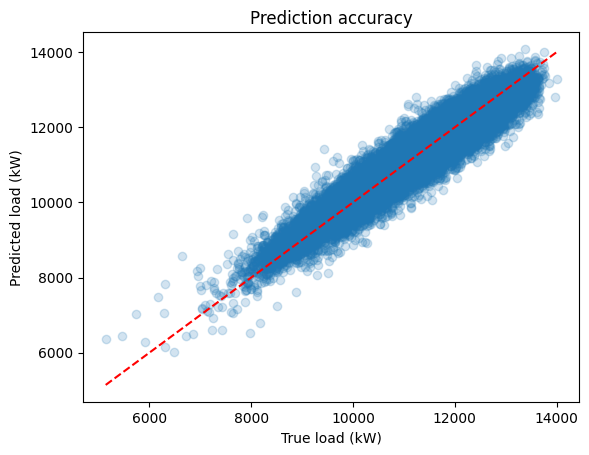

In [10]:

plt.scatter(y_eval_fe, y_eval_pred_fe, alpha=0.2)
plt.plot([y_eval_fe.min(), y_eval_fe.max()],
         [y_eval_fe.min(), y_eval_fe.max()],
         "r--")  # perfect prediction line
plt.xlabel("True load (kW)")
plt.ylabel("Predicted load (kW)")
plt.title("Prediction accuracy")
plt.show()


### 5.2 - timeseries plot | true vs predicted

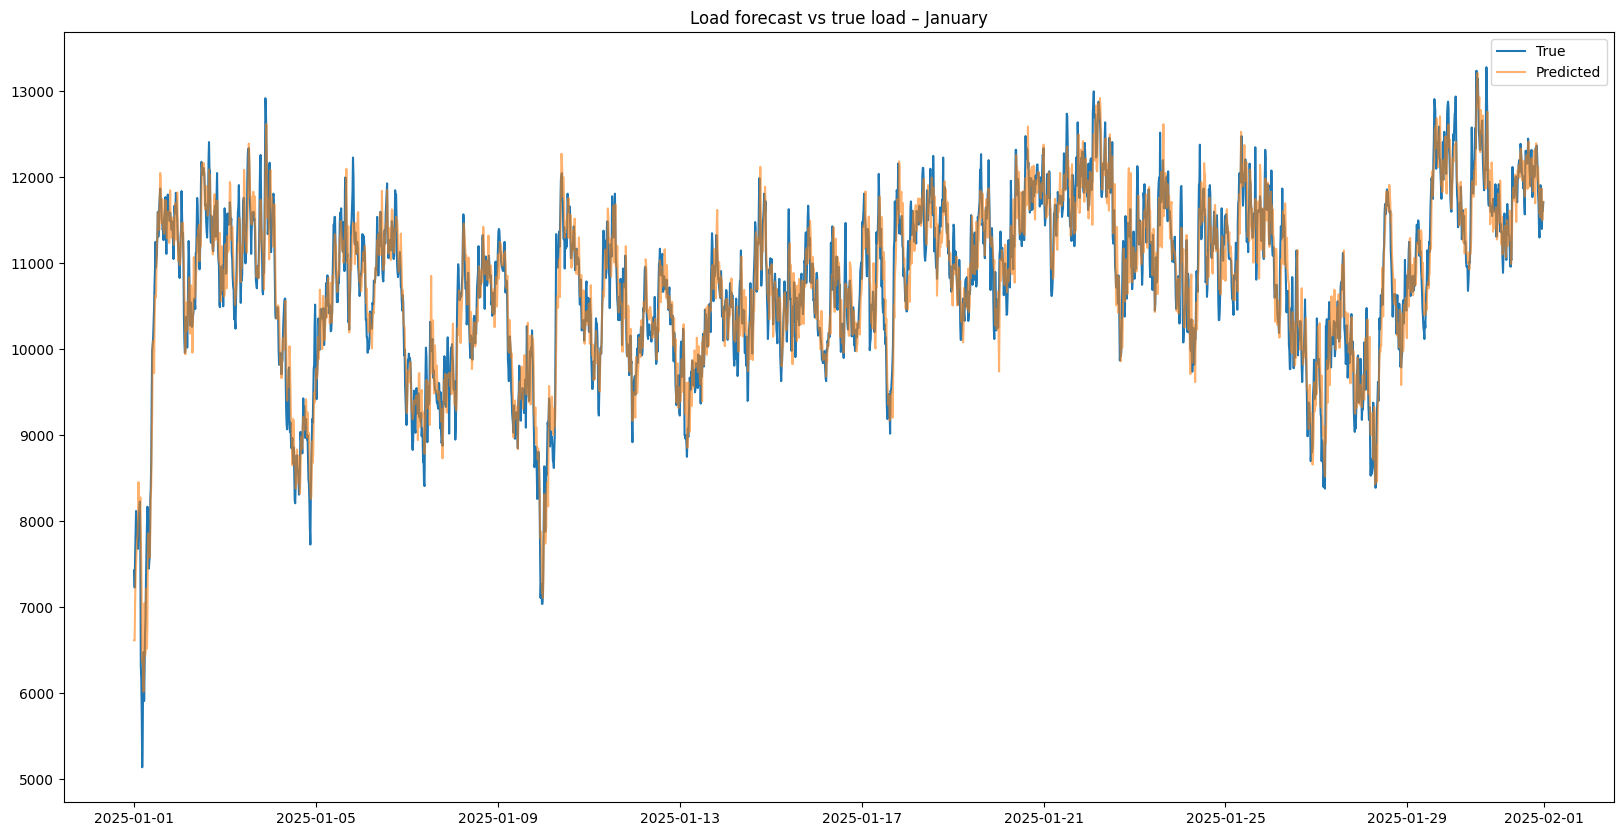

In [11]:
mask = y_eval_fe.index.month == 1

plt.figure(figsize=(20,10))
plt.plot(y_eval_fe.index[mask], y_eval_fe[mask], label="True")
plt.plot(y_eval_fe.index[mask], y_eval_pred_fe[mask], label="Predicted", alpha=0.6)

plt.legend()
plt.title("Load forecast vs true load – January")
plt.show()

### 5.3 - residual plot
- to see if there is a systematic error
- average line = 0 -> best
- random distribution (looks like a cloud) -> better
- some peak load predictions are not good

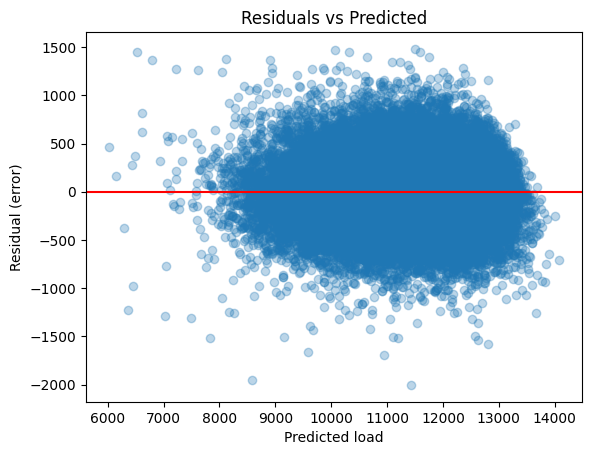

In [12]:
residuals = y_eval_fe - y_eval_pred_fe
plt.scatter(y_eval_pred_fe, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted load")
plt.ylabel("Residual (error)")
plt.show()


### 5.4 - distribution of residuals

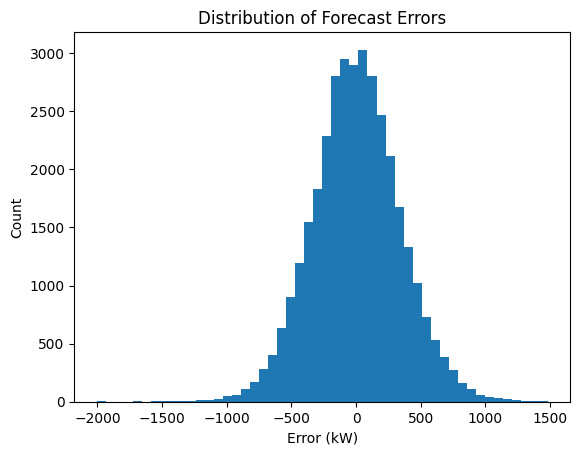

In [13]:

plt.hist(residuals, bins=50)
plt.title("Distribution of Forecast Errors")
plt.xlabel("Error (kW)")
plt.ylabel("Count")
plt.show()
